Simulação da Rede

In [25]:
import py_dss_interface
from py_dss_toolkit import dss_tools
import pandas as pd
import pickle

dss = py_dss_interface.DSS()

dss_file = r"C:\Dados_teste\OpenDSS\CBA\Alim_Meia_Ponte_5_REDUZIDO\Master_PyDSS_Interface.dss"
#dss_file = r"C:\Users\IVAN SANTOS\Documents\OpenDSS\Alim_Meia_Ponte_5_REDUZIDO\Master_PyDSS_Interface.dss"

dss_tools.update_dss(dss)

dss.text(f"compile [{dss_file}]")

cases = ["base", "60_gd", "60_gd_30_bess", "120_gd", "120_gd_60_bess"]
titles = {
    "base": "Caso Base",
    "60_gd": "Caso com 60 GDs",
    "60_gd_30_bess": "Caso com 60 GDs e 30 Baterias",
    "120_gd": "Caso com 120 GDs",
    "120_gd_60_bess": "Caso com 120 GDs e 60 Baterias",
}


dfs_monitor = {}
df_energymeter = pd.DataFrame(columns=["Caso", "Perdas (kWh)", "Energia (kWh)", "Energia injetada (kWh)"])
dfs_voltage = {}
dfs_monitor_pf = {}
dfs_storage = {}
dfs_monitor_pv = {}
dfs_battery = {}

for case in cases:
    dss.text("clear")
    dss.text(f"compile [{dss_file}]")

    if case == "60_gd":
        dss.text("Redirect 'PV_System_60_MeiaPonte.dss'")
        dss.text("Redirect 'Monitor_PV.dss'")
    
    elif case == "120_gd":
        dss.text("Redirect 'PV_System_120_MeiaPonte.dss'")
        dss.text("Redirect 'Monitores_PV_120.dss'")
    
    elif case == "60_gd_30_bess":
        dss.text("Redirect 'PV_System_60_MeiaPonte.dss'")

        #dss.text("Redirect 'BATERIAS_30.dss'")
        #dss.text("Redirect 'Battery_30.dss'")

        dss.text("Redirect 'Battery_SC_30.dss'")
        dss.text("Redirect 'StorageController_30.dss'")

        dss.text("Redirect 'Monitor_Baterias_30.dss'")

    elif case == "120_gd_60_bess":
        dss.text("Redirect 'PV_System_120_MeiaPonte.dss'")
        
        #dss.text("Redirect 'BATERIAS_60.dss'")
        #dss.text("Redirect 'Battery_60.dss'")

        dss.text("Redirect 'Battery_SC_60.dss'")
        dss.text("Redirect 'StorageController_60.dss'")
        
        dss.text("Redirect 'Monitor_Baterias_60.dss'")

    else:
        dss.text("!Redirect 'BATERIAS_60.dss'")
    
    dss.text(f"buscoords BusCoords.csv")

    dss.text("set mode=daily")
    dss.text("set stepsize=1h")
    dss.text("set number=1")

    socs = []

    for h in range(24):
        #if dss.solution.hour == 24:
            #dss.meters.reset_all()
        dss.solution.solve()

        if dss.storages.count > 0:
            dss.storages.first()
            dss.storages.next()   #Para pegar a bateria 2, comentar se for pegar a 1
            name_battery = dss.storages.name
            soc = dss.storages.pu_soc
            socs.append(soc)

    #dss.text("sample")

    if dss.storages.count > 0:
        dfs_storage[f"{name_battery}_{case}"] = socs

    meter_values = dss.meters.register_values

    #print(f"\n {titles[case]}\n")
    #print(f"Energia total: {meter_values[0]:.2f} kWh")
    #print(f"Perdas totais: {meter_values[12]:.2f} kWh\n")

    ##### Monitor - Power Flow Substation ####

    dfs_monitor[f"{case}_df"] = dss_tools.results.monitor("feeder")
    dfs_monitor[f"{case}_df"]["Total Power"] = dfs_monitor[f"{case}_df"][' P1 (kW)'] + dfs_monitor[f"{case}_df"][' P2 (kW)'] + dfs_monitor[f"{case}_df"][' P3 (kW)']

    ##### Monitors - Voltage #####

    monitor_names = dss.monitors.names

    for monitor_name in monitor_names:
        if "voltage" in monitor_name.lower():
            dfs_voltage[f"{monitor_name}_{case}_df"] = dss_tools.results.monitor(monitor_name)
        
        elif "battery" in monitor_name.lower():
            dfs_battery[f"{monitor_name}_{case}_df"] = dss_tools.results.monitor(monitor_name)
        ##### Monitors - Power Flow #####

        else:
            dfs_monitor_pf[f"{monitor_name}_{case}_df"] = dss_tools.results.monitor(monitor_name)

    
    injection = 0
    for chave, df in dfs_monitor_pf.items():    #Items() retorna a tupla (chave, item)

        if chave.endswith(f"_{case}_df") and "trf_" in chave:
            if " P3 (kW)" in df.columns:
                df["Total Power"] = df[" P1 (kW)"] + df[" P2 (kW)"] + df[" P3 (kW)"]
            else:
                df["Total Power"] = df[" P1 (kW)"] + df[" P2 (kW)"]

            #injection += df.query("`Total Power` < 0 and Hour > 24")["Total Power"].sum()  #Descomentar para 48h
            injection += df.query("`Total Power` < 0")["Total Power"].sum()   #Comentar para 48h


    ### Monitors - Geração PV

    for chave in dfs_monitor_pf:
        if chave.endswith(f"_{case}_df") and "pv_" in chave:
            dfs_monitor_pv[chave] = dfs_monitor_pf[chave]

    with open("dataframes.pkl", "wb") as f:
        pickle.dump(dfs_monitor_pv, f)

    ######## Criação do DataFrame "Energymeter" #####
    nova_linha = pd.DataFrame([{
        "Caso": titles[case], 
        "Energia (kWh)": meter_values[0], 
        "Perdas (kWh)": meter_values[12],
        "Energia injetada (kWh)": injection
    }])

    df_energymeter = pd.concat([df_energymeter, nova_linha], ignore_index=True)

#display(dfs_monitor["120_gd_60_bess_df"])

storages_soc_df = pd.DataFrame(dfs_storage)
#display(storages_soc_df)

display(df_energymeter)
print(dfs_voltage["voltage_trf_5286812a_120_gd_60_bess_df"].columns)


,Caso,Perdas (kWh),Energia (kWh),Energia injetada (kWh)
0,Caso Base,6277.866346,124421.081474,0.0
1,Caso com 60 GDs,5348.542958,78896.409729,-26567.828373
2,Caso com 60 GDs e 30 Baterias,4183.678368,80590.356505,-11286.218529
3,Caso com 120 GDs,5882.456263,49444.317416,-43688.849394
4,Caso com 120 GDs e 60 Baterias,3294.547157,46249.698588,-20508.826489


Index(['Hour', 'sec', ' V1', ' VAngle1', ' V2', ' VAngle2', ' V3', ' VAngle3',
       ' V4', ' VAngle4', ' I1', ' IAngle1', ' I2', ' IAngle2', ' I3',
       ' IAngle3', ' I4', ' IAngle4'],
      dtype='str')


Gráficos Tensão e Potência

,Caso,Perdas (kWh),Energia (kWh),Energia injetada (kWh)
0,Caso Base,6277.866346,124421.081474,0.0
1,Caso com 60 GDs,5348.542958,78896.409729,-26567.828373
2,Caso com 60 GDs e 30 Baterias,4183.678368,80590.356505,-11286.218529
3,Caso com 120 GDs,5882.456263,49444.317416,-43688.849394
4,Caso com 120 GDs e 60 Baterias,3294.547157,46249.698588,-20508.826489


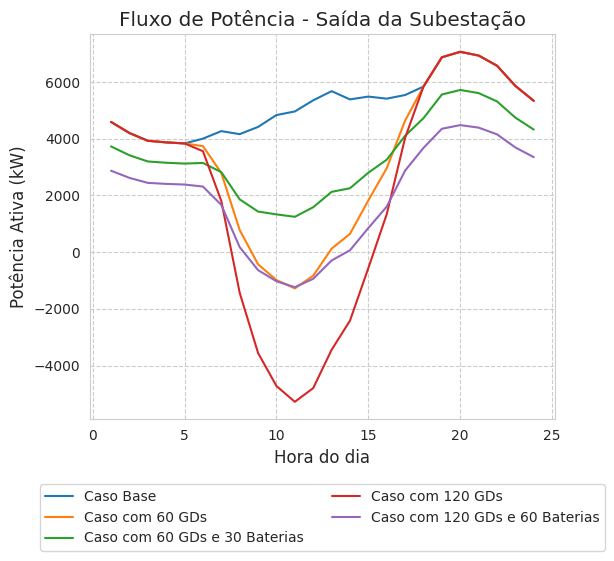

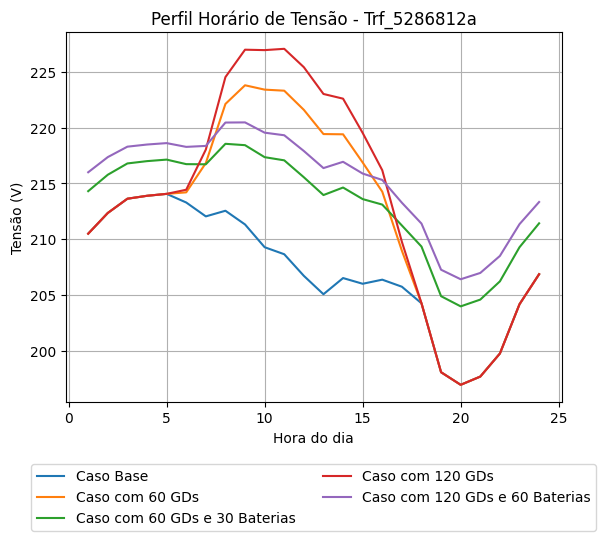

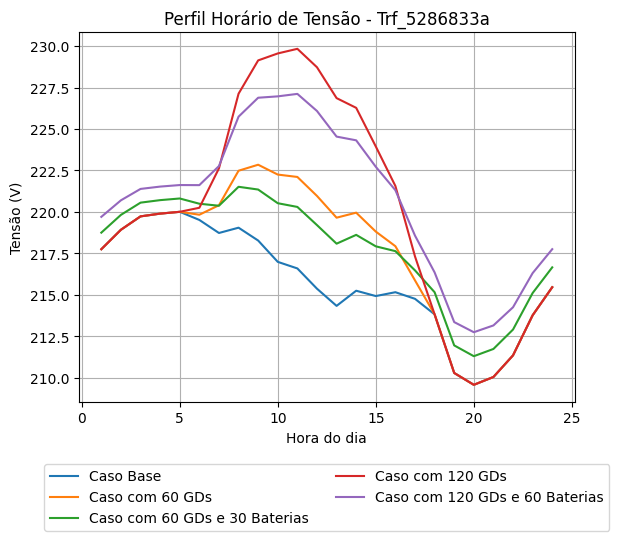

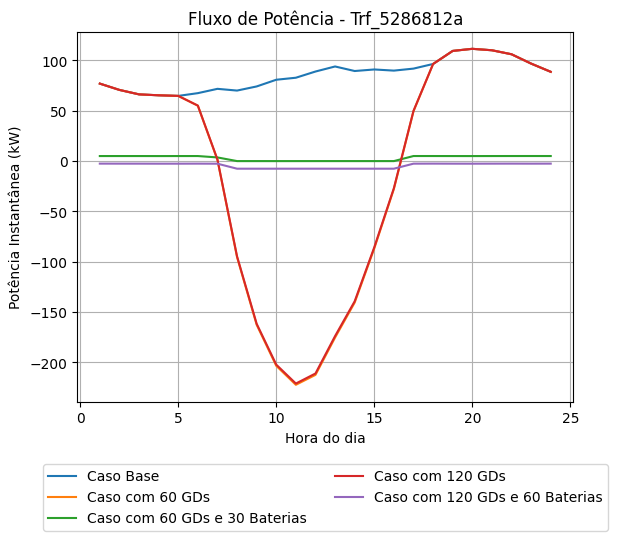

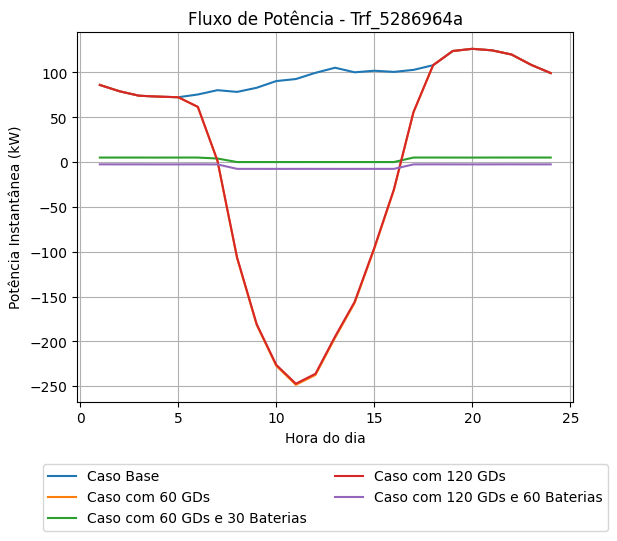

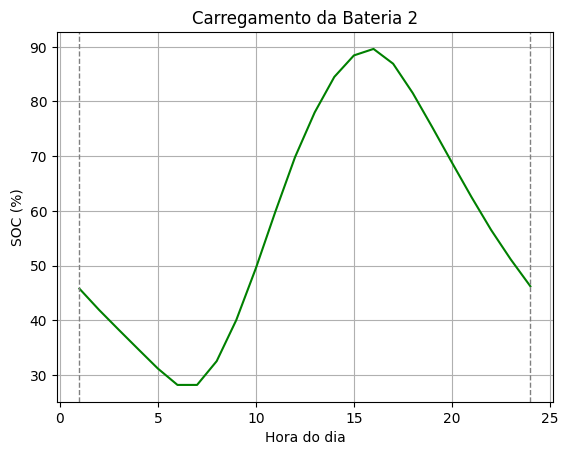

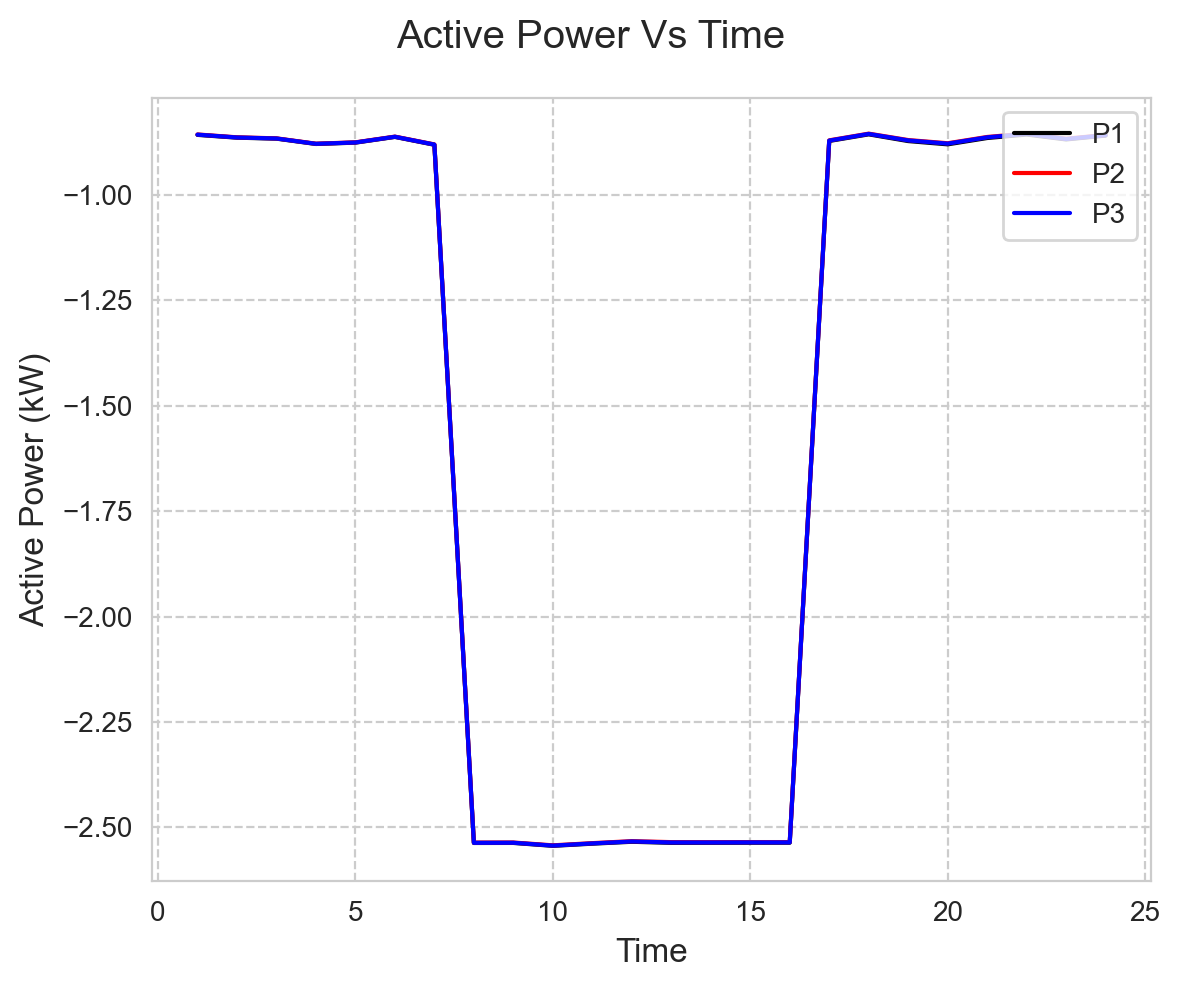

Hora 1: 45.76595986805439
Hora 24: 46.21167291225383


In [27]:
###### Resultados #####
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

display(df_energymeter)

titles = {
    "base": "Caso Base",
    "60_gd": "Caso com 60 GDs",
    "60_gd_30_bess": "Caso com 60 GDs e 30 Baterias",
    "120_gd": "Caso com 120 GDs",
    "120_gd_60_bess": "Caso com 120 GDs e 60 Baterias",
}
####### Gráfico Subestação Fluxo de Potência ####

x = np.linspace(1, 24, 24)
for case in cases:
    dfs_monitor[f"{case}_df"] = dfs_monitor[f"{case}_df"]
    plt.plot(
        x, 
        dfs_monitor[f"{case}_df"]["Total Power"], label=titles[case])
    

plt.title("Fluxo de Potência - Saída da Subestação")
plt.xlabel("Hora do dia")
plt.ylabel("Potência Ativa (kW)")
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)
plt.grid(True)
plt.style.use("default")
plt.show()

####### Gráfico Tensão Trf 5286812a ######
for case in cases:
    df1 = dfs_voltage[f"voltage_trf_5286812a_{case}_df"]
    plt.plot(
        x, 
        df1[" V1"], label=titles[case])
    
plt.title("Perfil Horário de Tensão - Trf_5286812a")
plt.xlabel("Hora do dia")
plt.ylabel("Tensão (V)")
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)
plt.grid(True)
plt.show()

###### Gráfico Tensão Trf_5286833a #####

for case in cases:
    df2= dfs_voltage[f"voltage_trf_5286833a_{case}_df"]
    plt.plot(
        x, 
        df2[" V1"], label=titles[case])
    
plt.title("Perfil Horário de Tensão - Trf_5286833a")
plt.xlabel("Hora do dia")
plt.ylabel("Tensão (V)")
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)
plt.grid(True)
#plt.style.use("dark_background")
plt.show()

#Fluxo de potência no trafo 5286812a

for case in cases:
    df3 = dfs_monitor_pf[f"trf_5286812a_{case}_df"]
    plt.plot(
        x, 
        df3["Total Power"], label=titles[case])
    
plt.title("Fluxo de Potência - Trf_5286812a")
plt.xlabel("Hora do dia")
plt.ylabel("Potência Instantânea (kW)")
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)
plt.grid(True)
plt.show()

#Fluxo de potência no trafo 5286812a

for case in cases:
    df4 = dfs_monitor_pf[f"trf_5286964a_{case}_df"]
    plt.plot(
        x, 
        df4["Total Power"], label=titles[case])
    
plt.title("Fluxo de Potência - Trf_5286964a")
plt.xlabel("Hora do dia")
plt.ylabel("Potência Instantânea (kW)")
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)
plt.grid(True)
plt.show()

##### Gráfico de carregamento ####


plt.plot(x, storages_soc_df["battery_2_60_gd_30_bess"]*100, color="green")
plt.axvline(x=24, color='gray', linestyle='--', linewidth=1)
plt.axvline(x=1, color='gray', linestyle='--', linewidth=1)
plt.xlabel("Hora do dia")
plt.ylabel("SOC (%)")
plt.title("Carregamento da Bateria 2")
plt.grid(True)
plt.show()

df_plotly = pd.DataFrame()
df_plotly["Hora"] = x
df_plotly["SOC (%)"] = storages_soc_df["battery_2_60_gd_30_bess"]*100
fig = px.line(df_plotly, x="Hora", y="SOC (%)", template="plotly_dark")
fig.show()

dss_tools.static_view.p_vs_time("trf_5286964a")

print("Hora 1:", df_plotly.loc[0, "SOC (%)"])
print("Hora 24:", df_plotly.loc[23, "SOC (%)"])



Storage Controller

In [24]:
import py_dss_interface
from py_dss_toolkit import dss_tools

dss = py_dss_interface.DSS()

dss_file = r"C:\Dados_teste\OpenDSS\CBA\Alim_Meia_Ponte_5_REDUZIDO\Master_PyDSS_Interface.dss"
#dss_file = r"C:\Users\IVAN SANTOS\Documents\OpenDSS\Alim_Meia_Ponte_5_REDUZIDO\Master_PyDSS_Interface.dss"

dss_tools.update_dss(dss)

dss.text(f"compile [{dss_file}]")
dss.text("Redirect 'Battery_60.dss'")

def sc_code_writer(bess):
    texto = ""

    trafo_df = dss_tools.model.transformers_df

    storages_list = dss_tools.model.storage_df
    storages_list = storages_list.head(bess)
    
    batteries_by_bus = storages_list.groupby("bus1")["name"].apply(list).reset_index()

    i = 0
    for i in range(len(batteries_by_bus["bus1"])):

        bus = batteries_by_bus["bus1"].iloc[i]

        trafo_name = trafo_df.query(f"bus == '{bus}'")["name"].iloc[0]

        baterias = batteries_by_bus["name"].iloc[i]

        texto += (
            f"New StorageController.SC_{i+1} element=Transformer.{trafo_name} terminal=1 modedis=peakShave elementList=[{baterias[0]}, {baterias[1]}]\n"
            f"~ MonPhase=AVG kwtarget=5 modecharge=peakShaveLow kwtargetLow=0\n\n"
        )

    with open(f"StorageController_{bess}.dss", "w", encoding="utf-8") as f:
        f.write(texto)


sc_code_writer(30)
sc_code_writer(60)

In [9]:
storages_list = dss_tools.model.storage_df

batteries_by_bus = storages_list.groupby("bus1")["name"].apply(list).reset_index()

display(batteries_by_bus)

,bus1,name
0,82020175286794.1.2.3.4,"[battery_19, battery_20]"
1,82021995286799.1.2.3.4,"[battery_43, battery_44]"
2,82022605286791.1.2.3.4,"[battery_49, battery_50]"
3,82023395286788.1.2.3.4,"[battery_11, battery_12]"
4,82025745286821.1.2.3.4,"[battery_7, battery_8]"
5,82026685286811.1.2.3.4,"[battery_47, battery_48]"
6,82026915286812.1.2.3.4,"[battery_3, battery_4]"
7,82027135286819.1.2.3.4,"[battery_35, battery_36]"
8,82027655286814.1.2.3.4,"[battery_37, battery_38]"
9,82027735286815.1.2.3.4,"[battery_25, battery_26]"


Baterias sem dispmode follow

In [1]:
import py_dss_interface
from py_dss_toolkit import dss_tools
import pandas as pd

dss = py_dss_interface.DSS()

dss_file = r"C:\Dados_teste\OpenDSS\CBA\Alim_Meia_Ponte_5_REDUZIDO\Master_PyDSS_Interface.dss"
#dss_file = r"C:\Users\IVAN SANTOS\Documents\OpenDSS\Alim_Meia_Ponte_5_REDUZIDO\Master_PyDSS_Interface.dss"

dss_tools.update_dss(dss)

dss.text(f"compile [{dss_file}]")

loads_df = dss_tools.model.loads_df

#Limpeza dos dados

floats = ["kv", "kw", "vmaxpu", "vminpu", "pf"]
strings = ["name", "daily", "conn"]

loads_df[floats] = loads_df[floats].astype(float)
loads_df[strings] = loads_df[strings].astype(str)
loads_df["phases"] = loads_df["phases"].astype(int)

loadshape_p = [0.63431595, 0.5781472, 0.53907255, 0.53100273, 0.525749, 0.5497442, 0.58774194, 0.57231744, 0.60902958, 0.66933898, 0.68768531, 0.7447487, 0.79201143, 0.74954746, 0.76405228, 0.75331663, 0.77208036, 0.81570054, 0.97013191, 1.0, 0.97971692, 0.92489638, 0.8190189, 0.74192983]
loadshape_q = [0.57151726, 0.51464415, 0.47607553, 0.46821595, 0.46296368, 0.48604702, 0.5237456, 0.50838673, 0.54647068, 0.61033922, 0.63035948, 0.69150093, 0.74493019, 0.6987781, 0.71553876, 0.703765, 0.72365629, 0.77090208, 0.9596657, 1.0, 0.97331006, 0.90212777, 0.77270589, 0.68527089]

loads_df = loads_df.sort_values(by="kw", ascending=False).reset_index(drop=True)
 
def code_writer(number, f):
    linhas = []
    for i in range(number):
        phase = loads_df.loc[i, "phases"]
        kv = loads_df.loc[i, "kv"]
        bus = loads_df.loc[i, "bus1"]
        kwrated = 2*loads_df.loc[i, "kw"]
        kwhrated = 16*loads_df.loc[i, "kw"]
        stored = "%stored=50"

        battery = f"New Storage.Battery_{i+1} phases={phase} bus1={bus} kv={kv} kWrated={kwrated} kWhrated={kwhrated} dispmode=follow {stored}"
        text =  battery + "\n\n"

        f.write(text)

        linhas.append({
            "Nome": f"Battery_{i + 1}",
            "Tensão (kV)": kv,
            "Bus": bus,
            "kW": kwrated,
            "kWh": kwhrated,
            "Fases": phase
        })

    battery_df = pd.DataFrame(linhas) 

    return battery_df


#30 Baterias
with open("Battery_SC_30.dss", "w", encoding="utf-8") as f:
    battery_df_30 = code_writer(30, f)

#60 Baterias
with open("Battery_SC_60.dss", "w", encoding="utf-8") as f:
    battery_df_60 = code_writer(60, f) 



